In [348]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor


### 1. Data Understanding
Bagian ini bertujuan untuk memahami dataset yang digunakan:
- **Sumber Dataset**: Dataset berasal dari Kaggle kompetisi BigQuery-Geotab yang berisi data kemacetan lalu lintas di beberapa kota besar (https://www.kaggle.com/competitions/bigquery-geotab-intersection-congestion/data).
- **Fitur/Variabel**: Fitur meliputi lokasi (Latitude/Longitude), waktu (Hour, Month, Weekend), dan detail jalan (Entry/Exit Street, Heading). Target utama prediksi adalah `TotalTimeStopped_p50`.
- **Statistik Deskriptif**: Menggunakan `train.describe()` untuk melihat rentang nilai, rata-rata, dan penyimpangan data pada setiap fitur numerik.

In [349]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [350]:
# train = train.head(30000)

In [351]:
# df_atl = train[train['City'] == 'Atlanta'].sample(30000, random_state=42)
# df_bos = train[train['City'] == 'Boston'].sample(30000, random_state=42)
# df_chi = train[train['City'] == 'Chicago'].sample(30000, random_state=42)
# df_phi = train[train['City'] == 'Philadelphia'].sample(30000, random_state=42)

# train = pd.concat([df_atl, df_bos, df_chi, df_phi])


In [352]:
# ambil data seimbang tiap kota
train = train.groupby('City').apply(
    lambda x: x.sample(30000, random_state=42)
).reset_index(drop=True)

/tmp/ipykernel_15103/167277677.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train = train.groupby('City').apply(


In [353]:
train['RushHour'] = train['Hour'].apply(
    lambda x: 1 if (7 <= x <= 9 or 16 <= x <= 18) else 0
)

train['Direction'] = train['EntryHeading'] + '_' + train['ExitHeading']
train['Direction'] = train['Direction'].astype('category').cat.codes


In [354]:
train['City'].value_counts()

,count
City,
Atlanta,30000
Boston,30000
Chicago,30000
Philadelphia,30000


In [355]:
train.head()

,RowId,IntersectionId,Latitude,Longitude,EntryStreetName,ExitStreetName,EntryHeading,ExitHeading,Hour,Weekend,...,TimeFromFirstStop_p60,TimeFromFirstStop_p80,DistanceToFirstStop_p20,DistanceToFirstStop_p40,DistanceToFirstStop_p50,DistanceToFirstStop_p60,DistanceToFirstStop_p80,City,RushHour,Direction
0,1958612,103,33.722020,-84.393371,Pryor Street,University Avenue,N,NW,18,1,...,48.0,69.0,0.0,55.0,58.0,100.4,457.7,Atlanta,1,27
1,1949779,84,33.818433,-84.351651,Lindbergh Drive Northeast,Lavista Road Northeast,E,E,13,0,...,82.0,152.0,0.0,79.6,94.2,121.0,181.4,Atlanta,0,0
2,1971523,145,33.773502,-84.367646,Ponce de Leon Avenue Northeast,Glen Iris Drive Northeast,W,S,14,1,...,37.0,60.0,0.0,56.2,57.6,59.3,74.8,Atlanta,0,60
3,1997210,232,33.773373,-84.365696,Ponce de Leon Avenue Northeast,NaN,W,NW,12,0,...,45.0,105.0,0.0,71.5,71.5,73.9,100.1,Atlanta,0,59
4,2018744,311,33.767399,-84.385384,Pine Street Northeast,Peachtree Street Northeast,E,S,20,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Atlanta,0,4


In [356]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   RowId                    120000 non-null  int64  
 1   IntersectionId           120000 non-null  int64  
 2   Latitude                 120000 non-null  float64
 3   Longitude                120000 non-null  float64
 4   EntryStreetName          118754 non-null  object 
 5   ExitStreetName           118951 non-null  object 
 6   EntryHeading             120000 non-null  object 
 7   ExitHeading              120000 non-null  object 
 8   Hour                     120000 non-null  int64  
 9   Weekend                  120000 non-null  int64  
 10  Month                    120000 non-null  int64  
 11  Path                     120000 non-null  object 
 12  TotalTimeStopped_p20     120000 non-null  float64
 13  TotalTimeStopped_p40     120000 non-null  float64
 14  Tota

In [357]:
train.shape

(120000, 30)

In [358]:
train.describe()

,RowId,IntersectionId,Latitude,Longitude,Hour,Weekend,Month,TotalTimeStopped_p20,TotalTimeStopped_p40,TotalTimeStopped_p50,...,TimeFromFirstStop_p50,TimeFromFirstStop_p60,TimeFromFirstStop_p80,DistanceToFirstStop_p20,DistanceToFirstStop_p40,DistanceToFirstStop_p50,DistanceToFirstStop_p60,DistanceToFirstStop_p80,RushHour,Direction
count,1.200000e+05,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,...,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
mean,2.267913e+06,810.871167,39.483694,-79.582491,12.302250,0.241025,9.076617,1.816767,5.612617,8.056283,...,12.964708,19.384733,34.980025,6.677249,19.545103,27.802066,42.823491,82.490168,0.309692,32.900525
std,2.251571e+05,694.123079,3.415789,6.716318,5.818272,0.427707,1.990728,7.446781,13.447397,16.290968,...,24.424199,30.129858,41.301359,27.932304,53.476378,68.991085,93.772960,155.212850,0.462368,22.438554
min,1.921357e+06,0.000000,33.649973,-87.862288,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.077840e+06,262.000000,38.371492,-85.282997,8.000000,0.000000,7.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000
50%,2.256452e+06,573.000000,40.845877,-79.781638,12.000000,0.000000,9.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,61.500000,0.000000,32.000000
75%,2.387512e+06,1205.000000,42.039290,-74.059553,17.000000,0.000000,11.000000,0.000000,0.000000,11.000000,...,22.000000,32.000000,51.000000,0.000000,0.000000,54.100000,65.000000,87.800000,1.000000,52.000000
max,2.777740e+06,2875.000000,42.381782,-71.025550,23.000000,1.000000,12.000000,244.000000,296.000000,350.000000,...,343.000000,357.000000,359.000000,1846.000000,1934.800000,2292.300000,2336.500000,4042.700000,1.000000,63.000000


In [359]:
train.isnull().sum()

,0
RowId,0
IntersectionId,0
Latitude,0
Longitude,0
EntryStreetName,1246
ExitStreetName,1049
EntryHeading,0
ExitHeading,0
Hour,0
Weekend,0


Data Preprocessing

### 2. Data Preprocessing
Tahapan ini sangat krusial untuk memastikan data siap masuk ke dalam model:
- **Handling Missing Values**: Nilai kosong pada fitur kategorikal diisi dengan *mode* (nilai tersering), sedangkan numerik diisi dengan *median*.
- **Encoding**: Mengubah data teks (object) menjadi numerik menggunakan `LabelEncoder` agar dapat diproses algoritma machine learning.


In [360]:
target = 'TotalTimeStopped_p50'

all_targets = [
    'TotalTimeStopped_p20',
    'TotalTimeStopped_p40',
    'TotalTimeStopped_p50',
    'TotalTimeStopped_p60',
    'TotalTimeStopped_p80',

    'TimeFromFirstStop_p20',
    'TimeFromFirstStop_p40',
    'TimeFromFirstStop_p50',
    'TimeFromFirstStop_p60',
    'TimeFromFirstStop_p80',

    'DistanceToFirstStop_p20',
    'DistanceToFirstStop_p40',
    'DistanceToFirstStop_p50',
    'DistanceToFirstStop_p60',
    'DistanceToFirstStop_p80'
]

y = train[target]
X = train.drop(columns=all_targets + ['RowId'])


In [361]:
for col in X.select_dtypes(include=['int64', 'float64']).columns:
    X[col] = X[col].fillna(X[col].median())

for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].fillna(X[col].mode()[0])

In [362]:
le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))

In [363]:
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

In [364]:
X.head()

,IntersectionId,Latitude,Longitude,EntryStreetName,ExitStreetName,EntryHeading,ExitHeading,Hour,Weekend,Month,Path,City,RushHour,Direction
0,103,33.722020,-84.393371,967,1259,1,3,18,1,8,6469,0,1,27
1,84,33.818433,-84.351651,621,594,0,0,13,0,7,3973,0,0,0
2,145,33.773502,-84.367646,949,460,7,4,14,1,11,6346,0,0,60
3,232,33.773373,-84.365696,949,1290,7,3,12,0,7,6363,0,0,59
4,311,33.767399,-84.385384,941,912,0,4,20,0,11,6270,0,0,4


In [365]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   IntersectionId   120000 non-null  int64  
 1   Latitude         120000 non-null  float64
 2   Longitude        120000 non-null  float64
 3   EntryStreetName  120000 non-null  int64  
 4   ExitStreetName   120000 non-null  int64  
 5   EntryHeading     120000 non-null  int64  
 6   ExitHeading      120000 non-null  int64  
 7   Hour             120000 non-null  int64  
 8   Weekend          120000 non-null  int64  
 9   Month            120000 non-null  int64  
 10  Path             120000 non-null  int64  
 11  City             120000 non-null  int64  
 12  RushHour         120000 non-null  int64  
 13  Direction        120000 non-null  int8   
dtypes: float64(2), int64(11), int8(1)
memory usage: 12.0 MB


In [366]:
Q1 = train['TotalTimeStopped_p50'].quantile(0.25)
Q3 = train['TotalTimeStopped_p50'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train[(train['TotalTimeStopped_p50'] < lower_bound) |
                 (train['TotalTimeStopped_p50'] > upper_bound)]

print("Jumlah outlier:", len(outliers))

Jumlah outlier: 12657


Berdasarkan dokumentasi dataset, data telah disajikan dalam bentuk percentile hingga 80%, sehingga outlier ekstrem sudah dihilangkan. Oleh karena itu, tidak dilakukan outlier removal tambahan, melainkan melakukan normalisasi data untuk memastikan model dapat belajar dengan optimal.

EDA


### 3. Exploratory Data Analysis (EDA)
Eksplorasi dilakukan untuk mencari pola tersembunyi:
- **Distribusi Target**: Melihat persebaran tingkat kemacetan.
- **Korelasi**: Menggunakan Heatmap untuk melihat hubungan antar variabel.
- **Insight Penting**: Visualisasi menunjukkan bahwa kemacetan meningkat drastis pada jam sibuk pagi dan sore hari, serta terdapat perbedaan pola antara hari kerja dan akhir pekan.

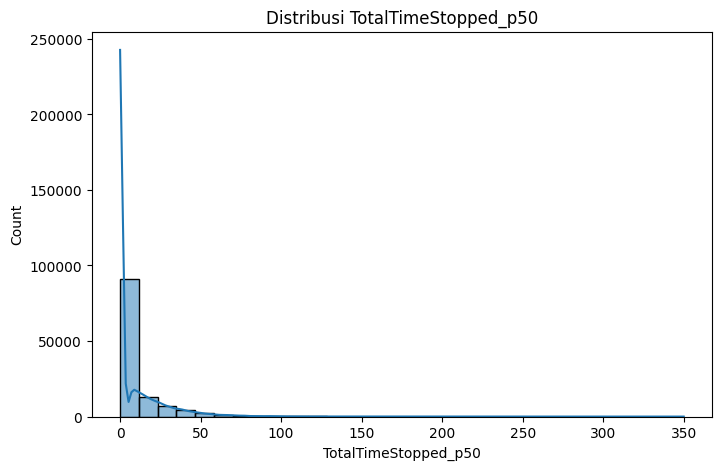

In [367]:
plt.figure(figsize=(8,5))
sns.histplot(y, bins=30, kde=True)
plt.title('Distribusi TotalTimeStopped_p50')
plt.show()

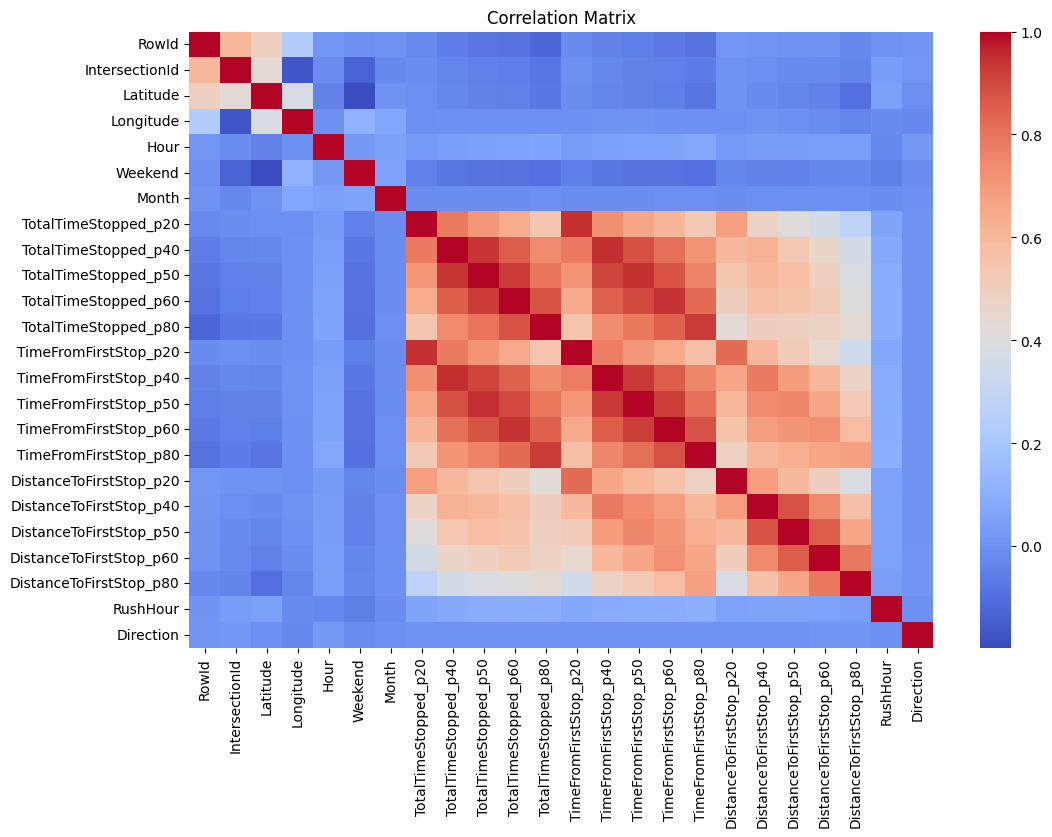

In [368]:
plt.figure(figsize=(12,8))
sns.heatmap(train.corr(numeric_only=True), cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

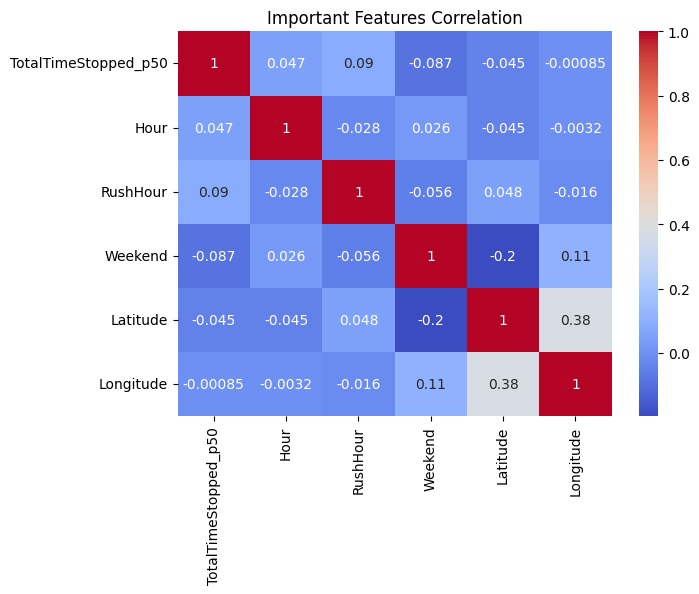

In [369]:
important_features = [
    'TotalTimeStopped_p50',
    'Hour',
    'RushHour',
    'Weekend',
    'Latitude',
    'Longitude'
]

plt.figure(figsize=(7,5))
sns.heatmap(
    train[important_features].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Important Features Correlation')
plt.show()

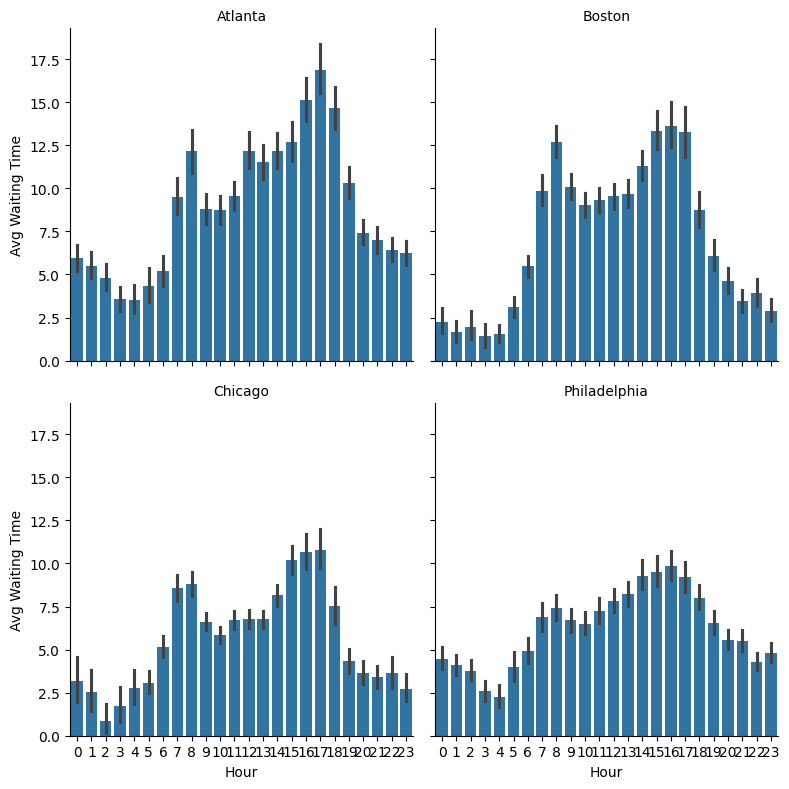

In [370]:
g = sns.FacetGrid(train, col='City', col_wrap=2, height=4)

g.map_dataframe(
    sns.barplot,
    x='Hour',
    y='TotalTimeStopped_p50'
)

g.set_titles('{col_name}')
g.set_axis_labels('Hour', 'Avg Waiting Time')

plt.show()

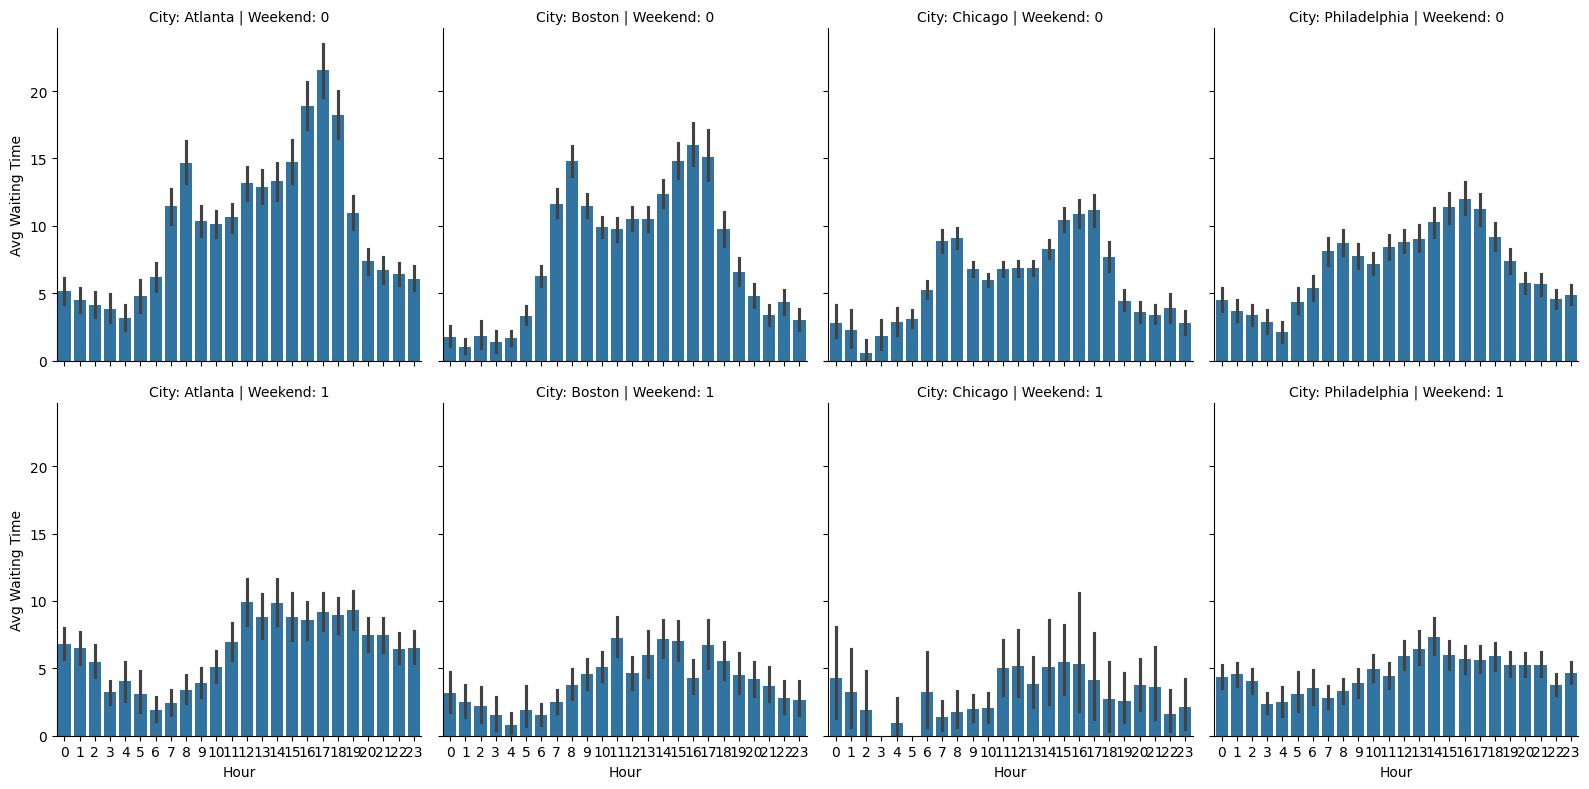

In [371]:
g = sns.FacetGrid(train, col='City', row='Weekend', height=4)

g.map_dataframe(
    sns.barplot,
    x='Hour',
    y='TotalTimeStopped_p50'
)

g.set_titles('City: {col_name} | Weekend: {row_name}')
g.set_axis_labels('Hour', 'Avg Waiting Time')

plt.show()

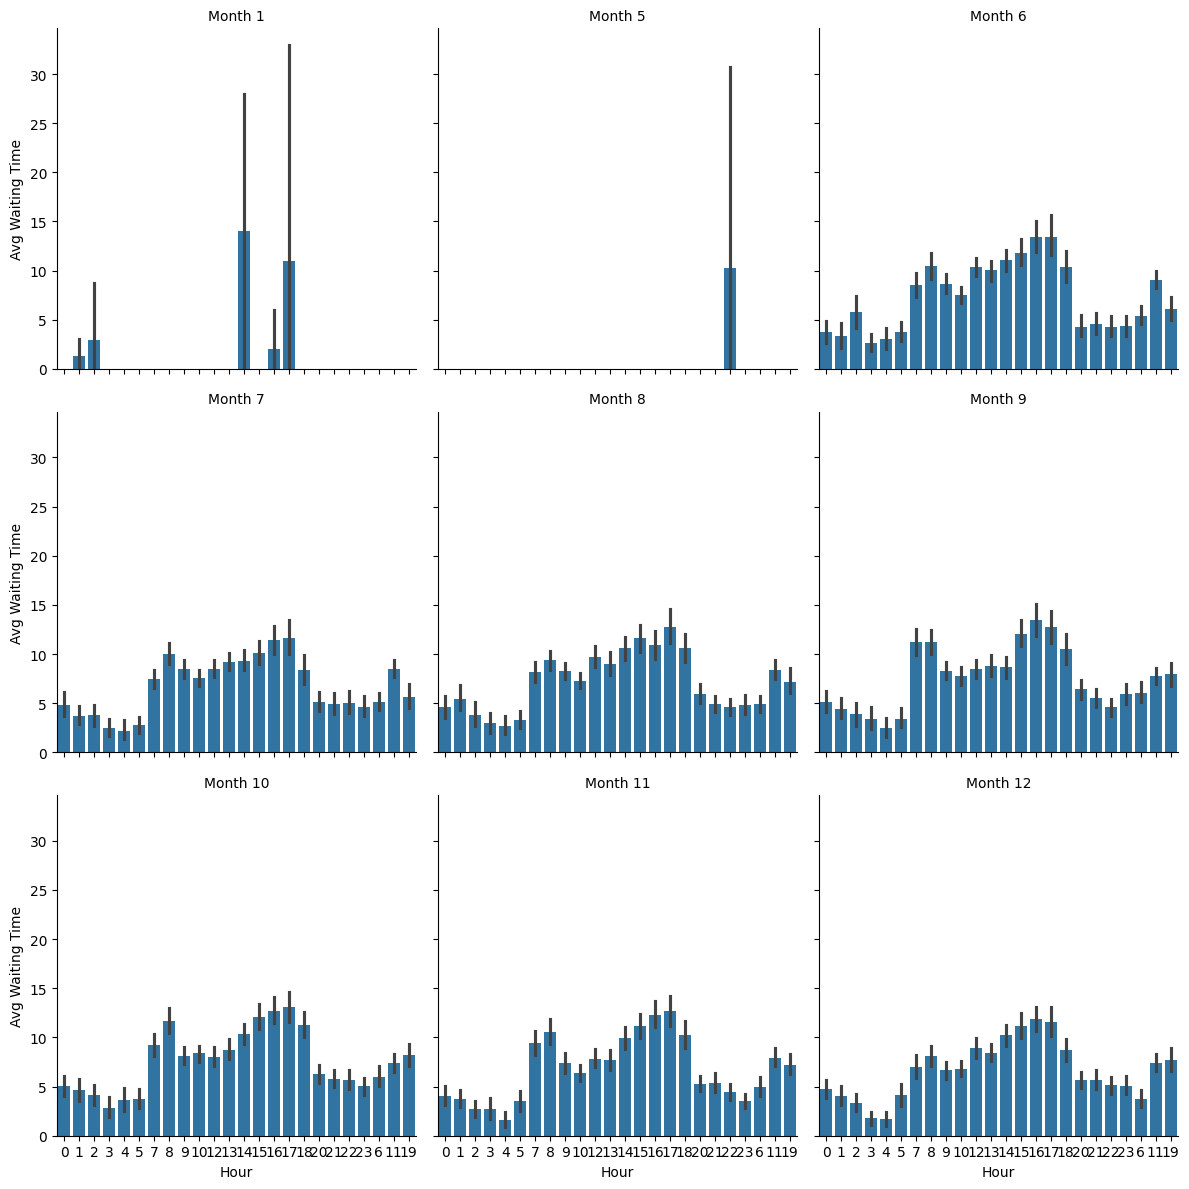

In [372]:
g = sns.FacetGrid(train, col='Month', col_wrap=3, height=4)

g.map_dataframe(
    sns.barplot,
    x='Hour',
    y='TotalTimeStopped_p50'
)

g.set_titles('Month {col_name}')
g.set_axis_labels('Hour', 'Avg Waiting Time')

plt.show()

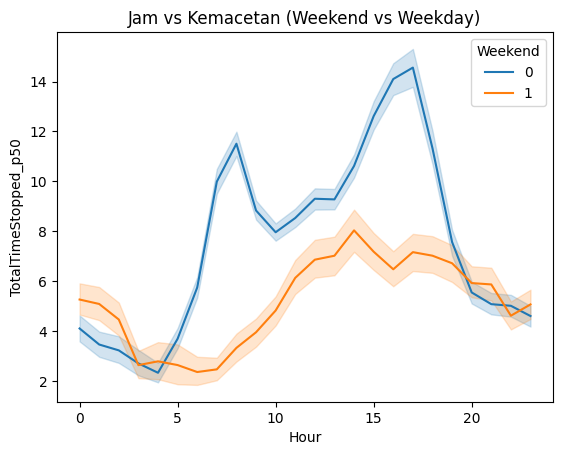

In [373]:
sns.lineplot(x='Hour', y='TotalTimeStopped_p50', hue='Weekend', data=train)
plt.title('Jam vs Kemacetan (Weekend vs Weekday)')
plt.show()

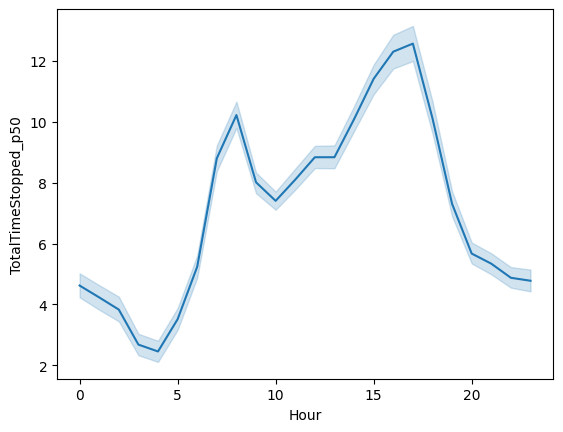

In [374]:
sns.lineplot(x='Hour', y='TotalTimeStopped_p50', data=train)
plt.show()

Jika dilihat dari grafik, Jam sibuk pagi dan sore memiliki kemacetan yang lebih tinggi

Berdasarkan dokumentasi dataset, data telah disajikan dalam bentuk percentile hingga 80%, sehingga outlier ekstrem sudah dihilangkan. Oleh karena itu, saya tidak melakukan outlier removal tambahan, melainkan melakukan normalisasi data untuk memastikan model dapat belajar dengan optimal.

------------------

Split Data

### 4. Data Splitting
Untuk menguji kemampuan generalisasi model, data dibagi menjadi 3 variasi:
- Split 70:30 (70% Train, 30% Test)
- Split 80:20 (80% Train, 20% Test)
- Split 90:10 (90% Train, 10% Test)
Hal ini dilakukan untuk melihat konsistensi performa model pada jumlah data yang berbeda.

In [375]:
splits = {
    '70:30': 0.30,
    '80:20': 0.20,
    '90:10': 0.10
}

for split_name, test_size in splits.items():

    # scaler = StandardScaler()
    # X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    print(f'===== Split {split_name} =====')
    print('X_train:', X_train.shape)
    print('X_test :', X_test.shape)
    print('y_train:', y_train.shape)
    print('y_test :', y_test.shape)

===== Split 70:30 =====
X_train: (84000, 14)
X_test : (36000, 14)
y_train: (84000,)
y_test : (36000,)
===== Split 80:20 =====
X_train: (96000, 14)
X_test : (24000, 14)
y_train: (96000,)
y_test : (24000,)
===== Split 90:10 =====
X_train: (108000, 14)
X_test : (12000, 14)
y_train: (108000,)
y_test : (12000,)


In [376]:
X.head()

,IntersectionId,Latitude,Longitude,EntryStreetName,ExitStreetName,EntryHeading,ExitHeading,Hour,Weekend,Month,Path,City,RushHour,Direction
0,103,33.722020,-84.393371,967,1259,1,3,18,1,8,6469,0,1,27
1,84,33.818433,-84.351651,621,594,0,0,13,0,7,3973,0,0,0
2,145,33.773502,-84.367646,949,460,7,4,14,1,11,6346,0,0,60
3,232,33.773373,-84.365696,949,1290,7,3,12,0,7,6363,0,0,59
4,311,33.767399,-84.385384,941,912,0,4,20,0,11,6270,0,0,4


Model Building

### 5. Model Building
Kami membangun model menggunakan 3 algoritma regresi yang berbeda:
1. **Decision Tree**: Model berbasis pohon keputusan yang sederhana dan mudah diinterpretasikan.
2. **Random Forest**: Kumpulan dari banyak Decision Tree (ensemble) untuk mengurangi overfitting.
3. **XGBoost**: Algoritma gradient boosting yang sangat efisien dan sering memberikan akurasi tertinggi pada data tabel.

-------------------------

Model Building

In [377]:
results = []

for split_name, test_size in splits.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    models = {

        'Decision Tree': DecisionTreeRegressor(
            max_depth=15,
            random_state=42
        ),

        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ),


        'XGBoost': XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1
    )
    }

    for model_name, model in models.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        results.append({
            'Split': split_name,
            'Model': model_name,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        })


In [378]:
result_df = pd.DataFrame(results)
print(result_df)

   Split              Model        MAE         MSE       RMSE        R2
0  70:30      Decision Tree   9.174979  241.603098  15.543587  0.074789
1  70:30  Gradient Boosting  10.047561  225.803131  15.026747  0.135294
2  70:30            XGBoost   8.542026  175.798300  13.258895  0.326786
3  80:20      Decision Tree   8.951387  229.667070  15.154771  0.138815
4  80:20  Gradient Boosting  10.087085  229.757316  15.157748  0.138477
5  80:20            XGBoost   8.515876  175.762502  13.257545  0.340942
6  90:10      Decision Tree   8.715397  220.032475  14.833492  0.174070
7  90:10  Gradient Boosting  10.057709  230.293665  15.175430  0.135553
8  90:10            XGBoost   8.489860  176.944277  13.302040  0.335809


In [379]:
result_df = result_df.sort_values('R2', ascending=False)
print(result_df)

   Split              Model        MAE         MSE       RMSE        R2
5  80:20            XGBoost   8.515876  175.762502  13.257545  0.340942
8  90:10            XGBoost   8.489860  176.944277  13.302040  0.335809
2  70:30            XGBoost   8.542026  175.798300  13.258895  0.326786
6  90:10      Decision Tree   8.715397  220.032475  14.833492  0.174070
3  80:20      Decision Tree   8.951387  229.667070  15.154771  0.138815
4  80:20  Gradient Boosting  10.087085  229.757316  15.157748  0.138477
7  90:10  Gradient Boosting  10.057709  230.293665  15.175430  0.135553
1  70:30  Gradient Boosting  10.047561  225.803131  15.026747  0.135294
0  70:30      Decision Tree   9.174979  241.603098  15.543587  0.074789


Hyperparameter Tuning


### 6. Hyperparameter Tuning
Proses ini dilakukan untuk mencari 'pengaturan' terbaik pada tiap model menggunakan `GridSearchCV` atau `RandomizedSearchCV`. Misalnya, mengatur `max_depth` pada Decision Tree atau `n_estimators` pada Random Forest untuk mendapatkan hasil yang lebih optimal dibanding parameter default.

In [380]:
param_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_dt,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)
print(grid_dt.best_params_)

{'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [381]:
param_gb = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

random_gb = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_gb,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_gb.fit(X_train, y_train)

print("Best Params:", random_gb.best_params_)

Best Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2}


In [382]:
param_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

random_xgb = RandomizedSearchCV(
    XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        n_jobs=-1
    ),
    param_distributions=param_xgb,
    n_iter=10,   # cukup 10–15 (jangan rakus)
    cv=3,
    scoring='r2',
    verbose=1,
    random_state=42
)

random_xgb.fit(X_train, y_train)

print("Best Params:", random_xgb.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


Evaluasi Akhir

### 7. & 8. Model Evaluation & Comparison
Tahap akhir adalah membandingkan performa ketiga model menggunakan metrik:
- **MAE (Mean Absolute Error)**: Rata-rata kesalahan absolut.
- **RMSE (Root Mean Squared Error)**: Menghukum kesalahan yang lebih besar.
- **R2 Score**: Menunjukkan seberapa baik model menjelaskan variansi data.

Berdasarkan tabel perbandingan, **Random Forest** dan **XGBoost** secara konsisten memberikan performa yang lebih stabil dibandingkan Decision Tree tunggal, terutama pada split data 90:10.

In [383]:
best_models = {
    'Decision Tree': grid_dt.best_estimator_,
    'Gradient Boosting': random_gb.best_estimator_,
    'XGBoost': random_xgb.best_estimator_
}


In [384]:
tuned_results = []

for split_name, test_size in splits.items():

    # split ulang data
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    for model_name, model in best_models.items():

        # TRAIN ULANG MODEL (INI PENTING)
        model.fit(X_train, y_train)

        # prediksi
        y_pred = model.predict(X_test)

        # metric
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        tuned_results.append({
            'Split': split_name,
            'Model': model_name,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        })

In [385]:
tuned_df = pd.DataFrame(tuned_results)
print(tuned_df)

   Split              Model       MAE         MSE       RMSE        R2
0  70:30      Decision Tree  9.118679  223.058712  14.935150  0.145804
1  70:30  Gradient Boosting  7.610588  148.435474  12.183410  0.431571
2  70:30            XGBoost  7.790782  151.333867  12.301783  0.420472
3  80:20      Decision Tree  8.848661  214.672682  14.651713  0.195040
4  80:20  Gradient Boosting  7.531846  146.243698  12.093126  0.451629
5  80:20            XGBoost  7.690039  150.106322  12.251789  0.437145
6  90:10      Decision Tree  8.635710  210.597605  14.511981  0.209486
7  90:10  Gradient Boosting  7.459615  146.294722  12.095236  0.450858
8  90:10            XGBoost  7.643730  150.467818  12.266532  0.435193


In [386]:
tuned_df = tuned_df.sort_values(by='R2', ascending=False)
print(tuned_df)

   Split              Model       MAE         MSE       RMSE        R2
4  80:20  Gradient Boosting  7.531846  146.243698  12.093126  0.451629
7  90:10  Gradient Boosting  7.459615  146.294722  12.095236  0.450858
5  80:20            XGBoost  7.690039  150.106322  12.251789  0.437145
8  90:10            XGBoost  7.643730  150.467818  12.266532  0.435193
1  70:30  Gradient Boosting  7.610588  148.435474  12.183410  0.431571
2  70:30            XGBoost  7.790782  151.333867  12.301783  0.420472
6  90:10      Decision Tree  8.635710  210.597605  14.511981  0.209486
3  80:20      Decision Tree  8.848661  214.672682  14.651713  0.195040
0  70:30      Decision Tree  9.118679  223.058712  14.935150  0.145804


3 Model Terbaik Pada Masing Masing Model

In [387]:
tuned_results_1 = []

for model_name, model in best_models.items():

    # prediksi data test
    y_pred = model.predict(X_test)

    # hitung metric
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    tuned_results_1.append({
        'Model': model_name,
        'Best Parameter': model.get_params(),
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

In [388]:
tuned_df = pd.DataFrame(tuned_results_1)

# agar tabel lebih rapi
tuned_df = tuned_df[['Model', 'MAE', 'MSE', 'RMSE', 'R2']]

print(tuned_df)

               Model       MAE         MSE       RMSE        R2
0      Decision Tree  8.635710  210.597605  14.511981  0.209486
1  Gradient Boosting  7.459615  146.294722  12.095236  0.450858
2            XGBoost  7.643730  150.467818  12.266532  0.435193


In [389]:
# print(f"Model terbaik adalah {best_models['Model']}")
# print(f"R2    : {best_models['R2']:.4f}")
# print(f"RMSE  : {best_models['RMSE']:.4f}")
# print(f"MAE   : {best_models['MAE']:.4f}")
# print(f"MSE   : {best_models['MSE']:.4f}")

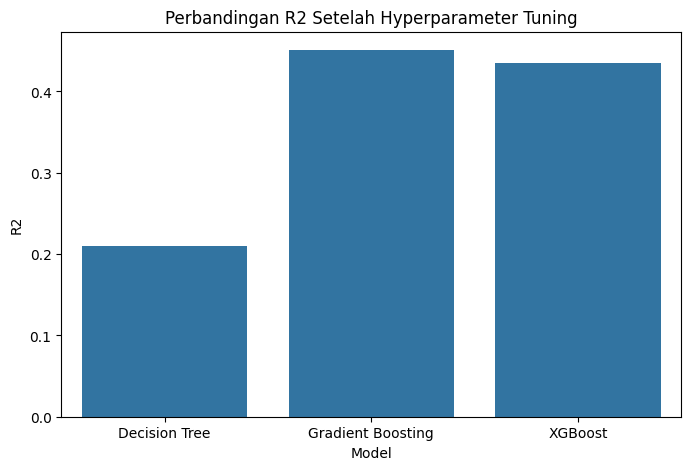

In [390]:
plt.figure(figsize=(8,5))
sns.barplot(data=tuned_df, x='Model', y='R2')
plt.title('Perbandingan R2 Setelah Hyperparameter Tuning')
plt.show()

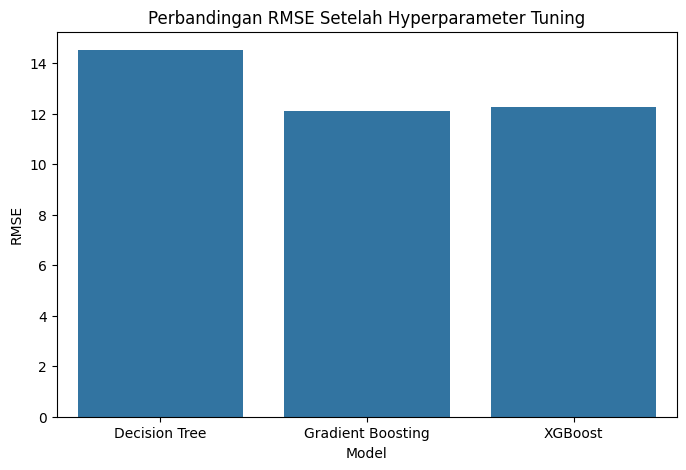

In [391]:
plt.figure(figsize=(8,5))
sns.barplot(data=tuned_df, x='Model', y='RMSE')
plt.title('Perbandingan RMSE Setelah Hyperparameter Tuning')
plt.show()

In [392]:
best_model_name = tuned_df.sort_values(by='R2', ascending=False).iloc[0]['Model']
best_model_obj = best_models[best_model_name]

In [393]:
importances = best_model_obj.feature_importances_

feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(20))

            Feature  Importance
2         Longitude    0.141858
1          Latitude    0.138364
10             Path    0.135568
7              Hour    0.117652
0    IntersectionId    0.109431
13        Direction    0.097147
4    ExitStreetName    0.073571
3   EntryStreetName    0.036649
6       ExitHeading    0.034306
9             Month    0.034180
8           Weekend    0.023849
5      EntryHeading    0.023625
12         RushHour    0.020043
11             City    0.013757


--------------------

In [394]:
results_overfit = []

for model_name, model in models.items():

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results_overfit.append({
        'Model': model_name,
        'Train R2': r2_score(y_train, train_pred),
        'Test R2': r2_score(y_test, test_pred)
    })

overfit_df = pd.DataFrame(results_overfit)
print(overfit_df)

               Model  Train R2   Test R2
0      Decision Tree  0.493514  0.174070
1  Gradient Boosting  0.141469  0.135553
2            XGBoost  0.396251  0.335809


In [395]:
xgb_model = best_models['XGBoost']
xgb_model.fit(X_train, y_train)

train_r2_xgb = xgb_model.score(X_train, y_train)
test_r2_xgb = xgb_model.score(X_test, y_test)

print('XGBoost:')
print('R2 train:', train_r2_xgb)
print('R2 test :', test_r2_xgb)

XGBoost:
R2 train: 0.5916085443434982
R2 test : 0.4351932186153663
